<a href="https://colab.research.google.com/github/BALJITrs7/GNN-IDS/blob/main/HostFlow_Gatv2_MultiClass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch-geometric -q

In [2]:
import os

import pandas as pd
import numpy as np

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from torch_geometric.data import Data

In [3]:
DATASET_DIR = "/Users/balji/OneDrive/GNN_IDS/Balanced_6Class_400K"

files = {
    "BENIGN.csv":0,
    "DDoS.csv":1,
    "DoS.csv":2,
    "Mirai.csv":3,
    "Recon.csv":4,
    "Spoofing.csv":5
}

dfs = []

for file,label in files.items():

    path = os.path.join(DATASET_DIR,file)

    df = pd.read_csv(path)

    if file == "BENIGN.csv":
        df = df.iloc[:40000].copy()

    attack_name = file.replace(".csv","")

    df["attack_type"] = attack_name

    df["label"] = label

    dfs.append(df)

data = pd.concat(
    dfs,
    ignore_index=True
)

print(data.shape)

print(data["attack_type"].value_counts())

(240000, 88)
attack_type
BENIGN      40000
DDoS        40000
DoS         40000
Mirai       40000
Recon       40000
Spoofing    40000
Name: count, dtype: int64


In [4]:
data = data.sort_values(
    "bidirectional_first_seen_ms"
).reset_index(drop=True)

data["flow_id"] = np.arange(len(data))

print(data.shape)

(240000, 89)


In [5]:
attack_type_backup = data["attack_type"].copy()

In [6]:
DROP_COLS = [

    "id",
    "expiration_id",

    "src_ip",
    "dst_ip",


   # "dst_port",
    #"src_port",
    #"protocol",
   # "ip_version"

    "src_mac",
    "dst_mac",

    "src_oui",
    "dst_oui",

    "requested_server_name",

    "client_fingerprint",
    "server_fingerprint",

    "user_agent",
    "content_type",

    "application_name",
    "application_category_name",

    "flow_id",
    "label",
    "attack_type",

    "bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",

    "src2dst_first_seen_ms",
    "src2dst_last_seen_ms",

    "dst2src_first_seen_ms",
    "dst2src_last_seen_ms",

    "application_confidence",
    "application_is_guessed",

    "vlan_id",
    "tunnel_id",

    "bidirectional_urg_packets",
    "src2dst_urg_packets",
    "dst2src_urg_packets",

    "dst2src_cwr_packets",
    "dst2src_ece_packets",

    "src_port",

    "bidirectional_duration_ms",
    "bidirectional_packets",

    "src2dst_packets",
    "dst2src_packets",

    "dst2src_min_ps",
    "dst2src_mean_ps",

    "bidirectional_min_piat_ms",
    "bidirectional_stddev_piat_ms",

    "dst2src_min_piat_ms",
    "dst2src_mean_piat_ms",
    "dst2src_max_piat_ms",

    "bidirectional_ece_packets",
    "bidirectional_psh_packets",
    "bidirectional_fin_packets",

    "src2dst_syn_packets",
    "src2dst_cwr_packets",
    "src2dst_ack_packets",
    "src2dst_rst_packets",
    "src2dst_fin_packets",

    "src2dst_mean_piat_ms",
    "src2dst_stddev_ps",

    "dst2src_ack_packets",
    "dst2src_psh_packets",
    "dst2src_rst_packets",
    "dst2src_fin_packets",

]

feature_cols = [

    c
    for c in data.columns
    if c not in DROP_COLS
]

print("Features:",len(feature_cols))

Features: 30


In [7]:
feature_cols = [
    c
    for c in data.columns
    if c not in DROP_COLS
]

print("Features:", len(feature_cols))

print("\nRetained Features:\n")
for i, f in enumerate(feature_cols, start=1):
    print(f"{i:2d}. {f}")

Features: 30

Retained Features:

 1. dst_port
 2. protocol
 3. ip_version
 4. bidirectional_bytes
 5. src2dst_duration_ms
 6. src2dst_bytes
 7. dst2src_duration_ms
 8. dst2src_bytes
 9. bidirectional_min_ps
10. bidirectional_mean_ps
11. bidirectional_stddev_ps
12. bidirectional_max_ps
13. src2dst_min_ps
14. src2dst_mean_ps
15. src2dst_max_ps
16. dst2src_stddev_ps
17. dst2src_max_ps
18. bidirectional_mean_piat_ms
19. bidirectional_max_piat_ms
20. src2dst_min_piat_ms
21. src2dst_stddev_piat_ms
22. src2dst_max_piat_ms
23. dst2src_stddev_piat_ms
24. bidirectional_syn_packets
25. bidirectional_cwr_packets
26. bidirectional_ack_packets
27. bidirectional_rst_packets
28. src2dst_ece_packets
29. src2dst_psh_packets
30. dst2src_syn_packets


In [8]:
top30 = {
    "bidirectional_mean_ps",
    "dst2src_syn_packets",
    "src2dst_min_ps",
    "ip_version",
    "src2dst_max_piat_ms",
    "dst2src_stddev_piat_ms",
    "bidirectional_max_piat_ms",
    "bidirectional_rst_packets",
    "src2dst_max_ps",
    "src2dst_duration_ms",
    "src2dst_bytes",
    "src2dst_ece_packets",
    "bidirectional_max_ps",
    "dst2src_bytes",
    "bidirectional_bytes",
    "dst2src_max_ps",
    "bidirectional_min_ps",
    "bidirectional_syn_packets",
    "dst2src_stddev_ps",
    "bidirectional_ack_packets",
    "protocol",
    "dst_port",
    "bidirectional_mean_piat_ms",
    "dst2src_duration_ms",
    "src2dst_mean_ps",
    "src2dst_min_piat_ms",
    "bidirectional_stddev_ps",
    "src2dst_stddev_piat_ms",
    "bidirectional_cwr_packets",
    "src2dst_psh_packets"
}

retained = set(feature_cols)

print("Missing from retained:")
print(sorted(top30 - retained))

print("\nExtra retained features:")
print(sorted(retained - top30))

Missing from retained:
[]

Extra retained features:
[]


In [9]:
for col in feature_cols:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

data[feature_cols] = (
    data[feature_cols]
    .fillna(0)
)

In [10]:
scaler = StandardScaler()

X = scaler.fit_transform(
    data[feature_cols]
)

print(X.shape)


(240000, 30)


In [11]:
all_hosts = pd.concat(
    [
        data["src_ip"],
        data["dst_ip"]
    ]
).unique()

host_to_id = {

    host : idx + len(data)

    for idx,host
    in enumerate(all_hosts)
}

num_flow_nodes = len(data)

num_host_nodes = len(all_hosts)

print("Flow Nodes:",num_flow_nodes)
print("Host Nodes:",num_host_nodes)

Flow Nodes: 240000
Host Nodes: 4087


In [12]:
edges = []

for flow_id,row in data.iterrows():

    src_host = host_to_id[
        row["src_ip"]
    ]

    dst_host = host_to_id[
        row["dst_ip"]
    ]

    edges.append(
        [flow_id,src_host]
    )

    edges.append(
        [src_host,flow_id]
    )

    edges.append(
        [flow_id,dst_host]
    )

    edges.append(
        [dst_host,flow_id]
    )

print("Host-flow edges built")

Host-flow edges built


In [13]:
src_groups = data.groupby(
    "src_ip"
)["flow_id"].apply(list)

print(
    "Groups:",
    len(src_groups)
)

Groups: 1213


In [14]:
# ==================================
# TEMPORAL FLOW-FLOW EDGES
# ==================================

src_groups = data.groupby("src_ip")["flow_id"].apply(list)

temporal_edges = 0

for flow_list in src_groups:

    n = len(flow_list)

    if n < 2:
        continue

    for i in range(n):

        f1 = flow_list[i]

        for k in [1, 2, 3]:

            if i + k < n:

                f2 = flow_list[i + k]

                edges.append([f1, f2])
                edges.append([f2, f1])

                temporal_edges += 2

print("Temporal edges added:", temporal_edges)
print("Total edges:", len(edges))

Temporal edges added: 1428984
Total edges: 2388984


In [15]:
edge_index = torch.tensor(edges,dtype=torch.long).t().contiguous()
print(edge_index.shape)



torch.Size([2, 2388984])


In [16]:
flow_features = torch.tensor(
    X,
    dtype=torch.float
)

In [17]:
host_features = torch.zeros(

    (
        num_host_nodes,
        flow_features.shape[1]
    ),

    dtype=torch.float
)

host_counts = np.zeros(
    num_host_nodes
)

for flow_id,row in data.iterrows():

    src_idx = (
        host_to_id[
            row["src_ip"]
        ]
        -
        num_flow_nodes
    )

    dst_idx = (
        host_to_id[
            row["dst_ip"]
        ]
        -
        num_flow_nodes
    )

    host_features[src_idx] += flow_features[flow_id]
    host_features[dst_idx] += flow_features[flow_id]

    host_counts[src_idx] += 1
    host_counts[dst_idx] += 1

for i in range(num_host_nodes):

    if host_counts[i] > 0:

        host_features[i] /= (
            host_counts[i]
        )

In [18]:
x = torch.cat(
    [
        flow_features,
        host_features
    ],
    dim=0
)

print(x.shape)

torch.Size([244087, 30])


In [19]:
flow_labels = torch.tensor(
    data["label"].values,
    dtype=torch.long
)

host_labels = torch.full(
    (
        num_host_nodes,
    ),
    -1,
    dtype=torch.long
)

y = torch.cat(
    [
        flow_labels,
        host_labels
    ]
)

print(y.shape)

torch.Size([244087])


In [20]:
flow_hosts = (
    data["src_ip"].astype(str)
    + "_"
    + data["dst_ip"].astype(str)
)

unique_pairs = flow_hosts.unique()

train_pairs, test_pairs = train_test_split(
    unique_pairs,
    test_size=0.2,
    random_state=42
)

train_idx = data[
    flow_hosts.isin(train_pairs)
].index.values

test_idx = data[
    flow_hosts.isin(test_pairs)
].index.values

print("Train flows:", len(train_idx))
print("Test flows :", len(test_idx))

print("Train pairs:", len(train_pairs))
print("Test pairs :", len(test_pairs))

Train flows: 192232
Test flows : 47768
Train pairs: 8880
Test pairs : 2220


In [21]:
#This cell is for Train/Test Split without Host pairs

#from sklearn.model_selection import train_test_split

#indices = np.arange(len(data))

#train_idx, test_idx = train_test_split(  indices, test_size=0.2, random_state=42, stratify=data["attack_type"] )

In [22]:
total_nodes = (
    num_flow_nodes
    +
    num_host_nodes
)

train_mask = torch.zeros(
    total_nodes,
    dtype=torch.bool
)

test_mask = torch.zeros(
    total_nodes,
    dtype=torch.bool
)

train_mask[
    train_idx
] = True

test_mask[
    test_idx
] = True

print("Train mask:", train_mask.sum().item())
print("Test mask :", test_mask.sum().item())

Train mask: 192232
Test mask : 47768


C:\Users\balji\AppData\Local\Temp\ipykernel_14896\2963144937.py:17: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  train_mask[


In [23]:

#scaler = StandardScaler()


#scaler.fit(data.loc[train_idx, feature_cols])


#X = scaler.transform(data[feature_cols])


#flow_features = torch.tensor(X, dtype=torch.float)

In [24]:
graph = Data(

    x=x,

    edge_index=edge_index,

    y=y,

    train_mask=train_mask,

    test_mask=test_mask
)

print(graph)

print(
    "Nodes:",
    graph.num_nodes
)

print(
    "Edges:",
    graph.num_edges
)

Data(x=[244087, 30], edge_index=[2, 2388984], y=[244087], train_mask=[244087], test_mask=[244087])
Nodes: 244087
Edges: 2388984


In [25]:
from torch_geometric.loader import NeighborLoader

print("Initializing Mini-Batch Loaders for GPU...")

# We use the [25, 15] neighbor limit and 2048 batch size that previously
# balanced well on your architecture.
train_loader = NeighborLoader(
    graph,
    num_neighbors=[15, 10],
    batch_size=2048,
    input_nodes=graph.train_mask,
    shuffle=True,
    num_workers=0
)

test_loader = NeighborLoader(
    graph,
    num_neighbors=[15, 10],
    batch_size=2048,
    input_nodes=graph.test_mask,
    shuffle=False,
    num_workers=0
)
print(f"Train subgraphs: {len(train_loader)} | Test subgraphs: {len(test_loader)}")

Initializing Mini-Batch Loaders for GPU...
Train subgraphs: 94 | Test subgraphs: 24


In [26]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv

class GATModel(torch.nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels,
        num_classes,
        heads=4
    ):
        super().__init__()

        # Layer 1
        self.conv1 = GATv2Conv(
            in_channels,
            hidden_channels // heads,
            heads=heads
        )

        # Layer 2
        self.conv2 = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads
        )

        # Layer 3: Output matches hidden_channels // 2 (128)
        self.conv3 = GATv2Conv(
            hidden_channels,
            (hidden_channels // 2) // heads,
            heads=heads
        )

        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)
        self.bn2 = torch.nn.BatchNorm1d(hidden_channels)
        self.bn3 = torch.nn.BatchNorm1d(hidden_channels // 2)

        self.classifier = torch.nn.Linear(
            hidden_channels // 2,
            num_classes
        )

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.4, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.4, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        x = self.classifier(x)

        return x

In [27]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [28]:
model = GATModel(
    in_channels=graph.num_node_features,
    hidden_channels=256,
    num_classes=6,
    heads=4
)

model = model.to(device)
graph = graph.to(device)

print(model)

GATModel(
  (conv1): GATv2Conv(30, 64, heads=4)
  (conv2): GATv2Conv(256, 64, heads=4)
  (conv3): GATv2Conv(256, 32, heads=4)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Linear(in_features=128, out_features=6, bias=True)
)


In [29]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.002,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=20,
    gamma=0.5
)

In [30]:


criterion = torch.nn.CrossEntropyLoss()


In [31]:
def train_epoch():
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        # Forward pass on the subgraph
        out = model(batch.x, batch.edge_index)

        # SLICE: Calculate loss strictly for the seed nodes
        loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.batch_size

    return total_loss / graph.train_mask.sum().item()

@torch.no_grad()
def evaluate_epoch(loader, mask_size):
    model.eval()
    correct = 0

    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)

        # Evaluate strictly for the seed nodes
        pred = out[:batch.batch_size].argmax(dim=1)
        y_true = batch.y[:batch.batch_size]

        correct += (pred == y_true).sum().item()

    return correct / mask_size



In [32]:
# Training Execution
for epoch in range(1, 51):
    loss = train_epoch()
    train_acc = evaluate_epoch(train_loader, graph.train_mask.sum().item())
    test_acc = evaluate_epoch(test_loader, graph.test_mask.sum().item())

    scheduler.step()

    print(f"Epoch {epoch:02d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Epoch 01 | Loss: 0.7220 | Train Acc: 0.8379 | Test Acc: 0.6936
Epoch 02 | Loss: 0.4606 | Train Acc: 0.8659 | Test Acc: 0.7272
Epoch 03 | Loss: 0.4035 | Train Acc: 0.8763 | Test Acc: 0.7442
Epoch 04 | Loss: 0.3629 | Train Acc: 0.8913 | Test Acc: 0.7585
Epoch 05 | Loss: 0.3296 | Train Acc: 0.9041 | Test Acc: 0.6021
Epoch 06 | Loss: 0.3044 | Train Acc: 0.9120 | Test Acc: 0.6595
Epoch 07 | Loss: 0.2860 | Train Acc: 0.9195 | Test Acc: 0.6301
Epoch 08 | Loss: 0.2714 | Train Acc: 0.9250 | Test Acc: 0.6533
Epoch 09 | Loss: 0.2590 | Train Acc: 0.9267 | Test Acc: 0.6237
Epoch 10 | Loss: 0.2443 | Train Acc: 0.9290 | Test Acc: 0.6192
Epoch 11 | Loss: 0.2378 | Train Acc: 0.9308 | Test Acc: 0.7124
Epoch 12 | Loss: 0.2230 | Train Acc: 0.9407 | Test Acc: 0.6454
Epoch 13 | Loss: 0.2134 | Train Acc: 0.9431 | Test Acc: 0.6708
Epoch 14 | Loss: 0.1986 | Train Acc: 0.9434 | Test Acc: 0.6543
Epoch 15 | Loss: 0.1943 | Train Acc: 0.9487 | Test Acc: 0.6578
Epoch 16 | Loss: 0.1844 | Train Acc: 0.9495 | Test Acc:

In [33]:
model.eval()

all_preds = []

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        out = model(
            batch.x,
            batch.edge_index
        )

        batch_pred = out[:batch.batch_size].argmax(dim=1)

        all_preds.extend(
            batch_pred.cpu().numpy()
        )

pred = torch.tensor(all_preds)

print("Predictions:", pred.shape)

Predictions: torch.Size([47768])


In [34]:
from sklearn.metrics import (
    classification_report
)

y_true = graph.y[graph.test_mask].cpu().numpy()
y_pred = pred.cpu().numpy()

test_rows = data.iloc[test_idx].reset_index(drop=True)

test_rows["pred"] = y_pred

print(
   classification_report(
    y_true,
    y_pred,
    target_names=[
        "Benign",
        "DDoS",
        "DoS",
        "Mirai",
        "Recon",
        "Spoofing"
    ],
    digits=5
)
)

              precision    recall  f1-score   support

      Benign    0.92743   0.97583   0.95101     14314
        DDoS    0.80884   0.81337   0.81110      7855
         DoS    0.88487   0.85622   0.87031       772
       Mirai    0.72740   0.95351   0.82525      7959
       Recon    0.95907   0.84683   0.89947      9741
    Spoofing    0.94748   0.66830   0.78377      7127

    accuracy                        0.87127     47768
   macro avg    0.87585   0.85234   0.85682     47768
weighted avg    0.88336   0.87127   0.87028     47768



In [35]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

class_names = [
    "Benign",
    "DDoS",
    "DoS",
    "Mirai",
    "Recon",
    "Spoofing"
]

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=[0,1,2,3,4,5],
    zero_division=0
)

results = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Support": support
})

results["Precision"] = results["Precision"].round(5)
results["Recall"] = results["Recall"].round(5)
results["F1"] = results["F1"].round(5)

print("\n===== CLASS-WISE PERFORMANCE =====\n")
print(results)


===== CLASS-WISE PERFORMANCE =====

      Class  Precision   Recall       F1  Support
0    Benign    0.92743  0.97583  0.95101    14314
1      DDoS    0.80884  0.81337  0.81110     7855
2       DoS    0.88487  0.85622  0.87031      772
3     Mirai    0.72740  0.95351  0.82525     7959
4     Recon    0.95907  0.84683  0.89947     9741
5  Spoofing    0.94748  0.66830  0.78377     7127


In [36]:
import pandas as pd

class_names = {
    0: "Benign",
    1: "DDoS",
    2: "DoS",
    3: "Mirai",
    4: "Recon",
    5: "Spoofing"
}

rows = []

for cls in range(6):

    mask = (y_true == cls)

    total = mask.sum()

    detected = (y_pred[mask] == cls).sum()

    recall = detected / total

    rows.append([
        class_names[cls],
        total,
        detected,
        recall
    ])

recall_df = pd.DataFrame(
    rows,
    columns=[
        "Class",
        "Total",
        "Detected",
        "Recall"
    ]
)

recall_df["Recall"] = recall_df["Recall"].round(5)

print("\n===== CLASS-WISE DETECTION =====\n")
print(recall_df)


===== CLASS-WISE DETECTION =====

      Class  Total  Detected   Recall
0    Benign  14314     13968  0.97583
1      DDoS   7855      6389  0.81337
2       DoS    772       661  0.85622
3     Mirai   7959      7589  0.95351
4     Recon   9741      8249  0.84683
5  Spoofing   7127      4763  0.66830


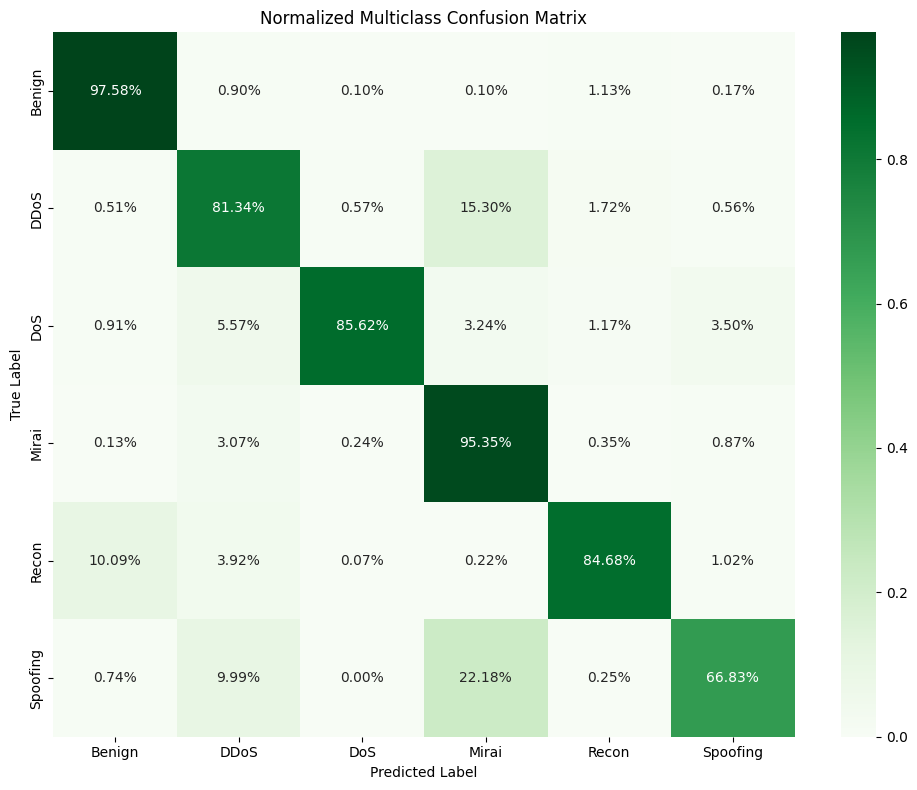

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# True labels
y_true = graph.y[graph.test_mask].cpu().numpy()

# Predicted labels
y_pred = pred.cpu().numpy()

# Class labels
labels = [
    "Benign",
    "DDoS",
    "DoS",
    "Mirai",
    "Recon",
    "Spoofing"
]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize row-wise
cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Multiclass Confusion Matrix")

plt.tight_layout()
plt.show()

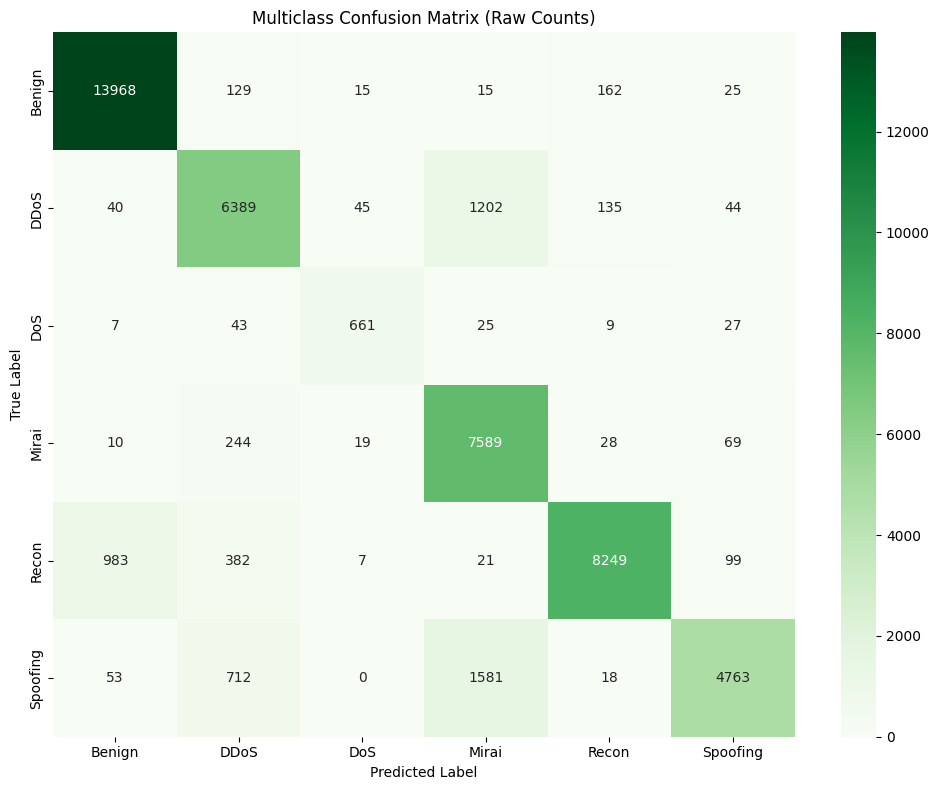

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Multiclass Confusion Matrix (Raw Counts)")
plt.tight_layout()
plt.show()

In [39]:
recon_rows = test_rows[
    test_rows["attack_type"] == "Recon"
]

recon_rows["pred"] = pd.Series(y_pred)

print(
    recon_rows["pred"]
    .value_counts()
)

pred
4    8249
0     983
1     382
5      99
3      21
2       7
Name: count, dtype: int64


In [40]:
recon_fn = recon_rows[
    recon_rows["pred"] == 0
]

print(recon_fn.head())

         id  expiration_id           src_ip            src_mac   src_oui  \
3032  12554              0  192.168.137.133  34:75:63:73:f3:36  34:75:63   
3119  17166              0  192.168.137.133  34:75:63:73:f3:36  34:75:63   
3128  17405              0  192.168.137.133  34:75:63:73:f3:36  34:75:63   
3566  25397              0  192.168.137.133  34:75:63:73:f3:36  34:75:63   
3837  31820              0  192.168.137.133  34:75:63:73:f3:36  34:75:63   

      src_port           dst_ip            dst_mac   dst_oui  dst_port  ...  \
3032     59003  111.235.248.121  3c:18:a0:41:c3:a0  3c:18:a0       123  ...   
3119     60763  111.235.248.121  3c:18:a0:41:c3:a0  3c:18:a0       123  ...   
3128     49900  111.235.248.121  3c:18:a0:41:c3:a0  3c:18:a0       123  ...   
3566     49281  111.235.248.121  3c:18:a0:41:c3:a0  3c:18:a0       123  ...   
3837     56411  111.235.248.121  3c:18:a0:41:c3:a0  3c:18:a0       123  ...   

      application_confidence  requested_server_name  client_fingerpr

In [41]:
recon_fn = recon_rows[
    recon_rows["pred"] == 0
]

print(
    recon_fn["src_ip"]
    .value_counts()
    .head(20)
)

src_ip
192.168.137.41               804
192.168.137.133              151
192.168.137.187                6
192.168.137.148                5
195.88.50.100                  5
18.182.200.45                  4
172.217.1.10                   4
205.174.165.69                 2
fe80::2a6d:97ff:fe9e:f4d5      1
142.251.41.74                  1
Name: count, dtype: int64


In [42]:
print(
    recon_rows["src_ip"]
    .nunique()
)

print(
    recon_fn["src_ip"]
    .nunique()
)

125
10


In [43]:
host = "192.168.137.41"

host_recon = recon_rows[
    recon_rows["src_ip"] == host
]

print(len(host_recon))

print(
    host_recon["pred"]
    .value_counts()
)

1557
pred
0    804
4    509
1    244
Name: count, dtype: int64


In [44]:
host = "192.168.137.41"

print(
    data[
        data["src_ip"] == host
    ]["attack_type"]
    .value_counts()
)

attack_type
BENIGN    18389
Recon      2480
DDoS        265
Mirai       166
DoS           6
Name: count, dtype: int64


In [45]:
host_rows = data[
    data["src_ip"] == "192.168.137.41"
]

print(
    host_rows["label"]
    .value_counts()
)

label
0    18389
4     2480
1      265
3      166
2        6
Name: count, dtype: int64


In [46]:
for host in [
    "192.168.137.41",
    "192.168.137.133",
    "192.168.137.1"
]:
    print("\n", host)
    print(
        data[data["src_ip"] == host]["attack_type"]
        .value_counts()
    )


 192.168.137.41
attack_type
BENIGN    18389
Recon      2480
DDoS        265
Mirai       166
DoS           6
Name: count, dtype: int64

 192.168.137.133
attack_type
BENIGN      5720
Recon        728
DDoS         589
Spoofing      11
Name: count, dtype: int64

 192.168.137.1
attack_type
Spoofing    5757
Mirai       2642
Recon       1607
DDoS        1441
DoS          819
BENIGN       293
Name: count, dtype: int64


In [47]:
host = "192.168.137.1"

host_test = test_rows[
    test_rows["src_ip"] == host
]

print(
    host_test.groupby("attack_type")["pred"]
    .mean()
    .sort_values()
)

attack_type
DDoS        1.163306
DoS         1.995465
BENIGN      2.448276
Mirai       2.984127
Recon       3.795374
Spoofing    5.000000
Name: pred, dtype: float64


In [48]:
host = "192.168.137.41"

host_test = test_rows[
    test_rows["src_ip"] == host
]

print(
    host_test.groupby("attack_type")["pred"]
    .mean()
    .sort_values()
)

attack_type
BENIGN    0.053881
Recon     1.464355
DDoS      2.014019
Mirai     2.823529
Name: pred, dtype: float64


In [49]:
host = "192.168.137.41"

host_test = test_rows[
    test_rows["src_ip"] == host
]

print(
    host_test.groupby("attack_type")
    .size()
)

attack_type
BENIGN    9057
DDoS       214
Mirai       34
Recon     1557
dtype: int64


In [50]:
host = "192.168.137.133"

host_test = test_rows[
    test_rows["src_ip"] == host
]

print(
    host_test.groupby("attack_type")
    .size()
)

attack_type
BENIGN      1289
DDoS         123
Recon        223
Spoofing       1
dtype: int64


In [51]:
host = "192.168.137.41"

host_test = test_rows[
    test_rows["src_ip"] == host
]

print(
    host_test.groupby("attack_type")["pred"]
    .mean()
)

attack_type
BENIGN    0.053881
DDoS      2.014019
Mirai     2.823529
Recon     1.464355
Name: pred, dtype: float64
